In [1]:
# Neural network libraries
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import segmentation_models as sm
sm.set_framework("tf.keras")

# Plotting
import matplotlib.pyplot as plt
%matplotlib inline

# DeepD3 
from deepd3.model import DeepD3_Model
from deepd3.training.stream import DataGeneratorStream

Segmentation Models: using `tf.keras` framework.


## Load training data

In [3]:
TRAINING_DATA_PATH = r"DeepD3_Training.d3set"
VALIDATION_DATA_PATH = r"DeepD3_Validation.d3set"

dg_training = DataGeneratorStream(TRAINING_DATA_PATH, 
                                  batch_size=32, # Data processed at once, depends on your GPU
                                  target_resolution=0.094, # fixed to 94 nm, can be None for mixed resolution training
                                  min_content=50) # images need to have at least 50 segmented px

dg_validation = DataGeneratorStream(VALIDATION_DATA_PATH, 
                                    batch_size=32, 
                                    target_resolution=0.094,
                                    min_content=50, 
                                    augment=False,
                                    shuffle=False)

## Visualize data

Glancing on the data to verify that settings are as expected.

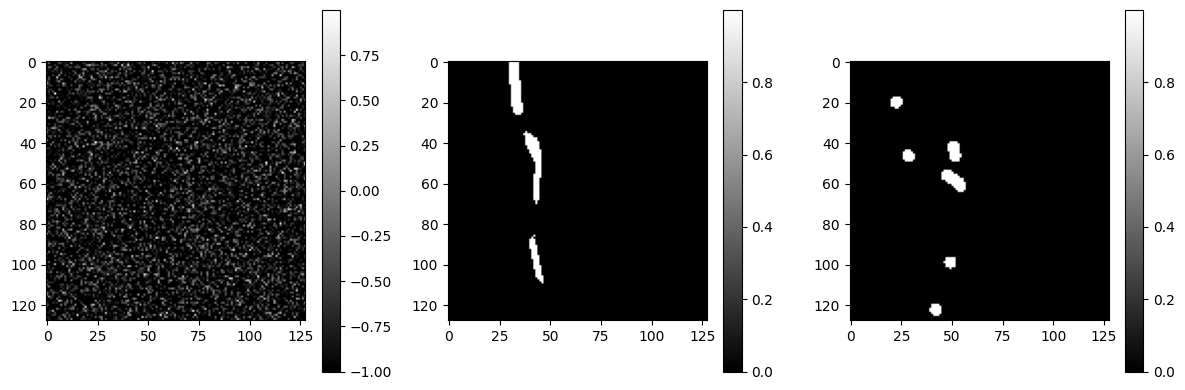

In [4]:
X, Y = dg_training[0]
i = 0

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(X[i].squeeze(), cmap='gray')
plt.colorbar()

plt.subplot(132)
plt.imshow(Y[0][i].squeeze(), cmap='gray')
plt.colorbar()

plt.subplot(133)
plt.imshow(Y[1][i].squeeze(), cmap='gray')
plt.colorbar()

plt.tight_layout()

## Creating model and set training parameters

In [5]:
# Create a naive DeepD3 model with a given base filter count (e.g. 32)
m = DeepD3_Model(filters=32)

# Set appropriate training settings
m.compile(Adam(learning_rate=0.0005), # optimizer, good default setting, can be tuned 
          [sm.losses.dice_loss, "mse"], # Dice loss for dendrite, MSE for spines
          metrics=['acc', sm.metrics.iou_score]) # Metrics for monitoring progress

m.summary()

2026-09-29 15:48:56.257238: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-09-29 15:48:56.257296: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-09-29 15:48:56.257306: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-09-29 15:48:56.257412: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-29 15:48:56.257474: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, 128, 128, 1)]        0         []                            
                                                                                                  
 enc_layer0_conv1 (Conv2D)   (None, 128, 128, 32)         288       ['input[0][0]']               
                                                                                                  
 enc_layer0_conv1_BN (Batch  (None, 128, 128, 32)         128       ['enc_layer0_conv1[0][0]']    
 Normalization)                                                                                   
                                                                                                  
 enc_layer0_conv1_activatio  (None, 128, 128, 32)         0         ['enc_layer0_conv1_BN[0][0

## Fitting model

Loading some training callbacks, such as adjusting the learning rate across time, saving training progress and intermediate models

In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, LearningRateScheduler

In [7]:
def schedule(epoch, lr):
    if epoch < 1:
        return lr
    
    else:
        return lr * tf.math.exp(-0.1)

# Train your own DeepD3 model

In [8]:
EPOCHS = 30

# Save best model automatically during training
mc = ModelCheckpoint("DeepD3_model.h5",
                            save_best_only=True)
        
# Save metrics  
csv = CSVLogger("DeepD3_model.csv")

# Adjust learning rate during training to allow for better convergence
lrs = LearningRateScheduler(schedule)

# Actually train the network
h = m.fit(dg_training, 
        batch_size=32, 
        epochs=EPOCHS, 
        validation_data=dg_validation, 
        callbacks=[mc, csv, lrs])

Epoch 1/30


2026-09-29 15:49:10.774798: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  92/1562 [>.............................] - ETA: 16:20 - loss: 0.9523 - dendrites_loss: 0.8654 - spines_loss: 0.0869 - dendrites_acc: 0.8794 - dendrites_iou_score: 0.0726 - spines_acc: 0.9538 - spines_iou_score: 0.0218

KeyboardInterrupt: 

## Save model for use in GUI or batch processing

This is for saving the neural network manually. The best model is automatically saved during training.

In [ ]:
m.save("deepd3_custom_trained_model.h5")

In [ ]:
import sys
import pyqtgraph as pg
from PyQt5.QtWidgets import QApplication

app = QApplication(sys.argv)
win = pg.GraphicsLayoutWidget()
win.setWindowTitle("Test")
win.show()
app.exec()   

0

In [ ]:
python -c "
from PyQt5.QtCore import QLibraryInfo
import os
path = QLibraryInfo.location(QLibraryInfo.LibrariesPath)
print(path)
"   